# 08 · Mid-term RL Unit 2 — Multi-Armed Bandit

Implement only **epsilon-greedy contextual bandits** for the mid-term.

- Arms = five wavelet choices.
- Context = the three signal-quality states from Notebook 07.
- Reward = per-recording reward from Notebook 06.
- The policy learns a separate action-value estimate for each state.

Do not run UCB, Thompson sampling, gradient bandits, or the full 2,100-action search in the mid-term notebook.


In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score

reward_data = joblib.load(P["processed"] / "midterm_reward_data.joblib")
states = np.load(P["processed"] / "midterm_states.npz")

wavelets = reward_data["wavelets"]
R = reward_data["reward_train"]
state_train = states["state_train"]

val_idx = reward_data["val_idx"]
state_val = states["state_val"]
y = reward_data["y"]
val_prob = reward_data["val_prob"]

K = 3
A = len(wavelets)
print("States:", K, "| Actions:", A, "| Wavelets:", wavelets)


Python environment is working
PyTorch: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


States: 3 | Actions: 5 | Wavelets: ['db4', 'db6', 'db8', 'sym4', 'coif3']


## Epsilon-greedy learning

Learned policy:
  state 0 -> sym4
  state 1 -> coif3
  state 2 -> coif3


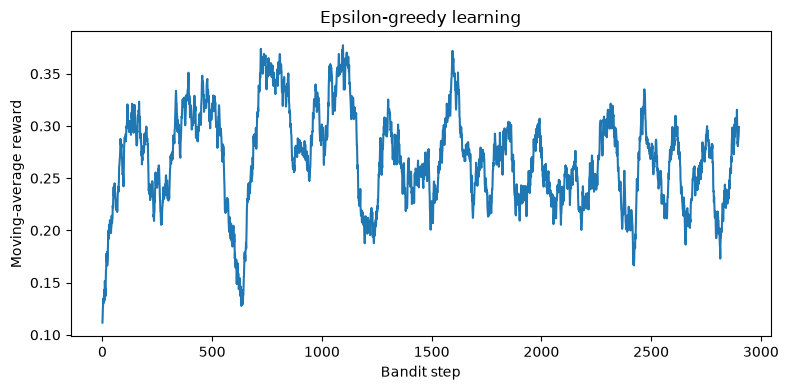

['C:\\Users\\roshh\\Desktop\\rl\\version 2\\results\\midsem\\midterm_epsilon_greedy_bandit.joblib']

In [2]:
def epsilon_greedy_bandit(R, state, steps=3000, epsilon=0.10, seed=42):
    rng = np.random.default_rng(seed)

    q = np.zeros((K, A), dtype=float)
    counts = np.zeros((K, A), dtype=int)
    rewards = []
    actions_taken = []

    state_indices = {
        s: np.where(state == s)[0]
        for s in range(K)
    }

    for step in range(steps):
        s = int(rng.integers(0, K))
        candidates = state_indices[s]

        if len(candidates) == 0:
            continue

        i = int(rng.choice(candidates))

        if rng.random() < epsilon:
            a = int(rng.integers(0, A))
        else:
            a = int(np.argmax(q[s]))

        r = float(R[i, a])

        counts[s, a] += 1
        q[s, a] += (r - q[s, a]) / counts[s, a]

        rewards.append(r)
        actions_taken.append((s, a))

    policy = np.argmax(q, axis=1)
    return {
        "q": q,
        "counts": counts,
        "policy": policy,
        "rewards": np.asarray(rewards),
        "actions": actions_taken
    }

out = epsilon_greedy_bandit(R, state_train, steps=3000, epsilon=0.10, seed=42)

print("Learned policy:")
for s, a in enumerate(out["policy"]):
    print(f"  state {s} -> {wavelets[a]}")

fig, ax = plt.subplots(figsize=(8, 4))
w = 100
smooth = np.convolve(out["rewards"], np.ones(w)/w, mode="valid")
ax.plot(smooth)
ax.set_xlabel("Bandit step")
ax.set_ylabel("Moving-average reward")
ax.set_title("Epsilon-greedy learning")
plt.tight_layout()
savefig(fig, "08_midterm_bandit_learning")
plt.show()

joblib.dump(out, P["results"] / "midterm_epsilon_greedy_bandit.joblib", compress=3)


## Evaluate the learned contextual policy on validation patients

In [3]:
def evaluate_context_policy(policy, state_values, prob_matrix, y_true):
    chosen = np.asarray(policy)[state_values]
    p = prob_matrix[np.arange(len(y_true)), chosen]
    pred = (p >= 0.5).astype(int)

    return {
        "macro_f1": f1_score(y_true, pred, average="macro"),
        "balanced_acc": balanced_accuracy_score(y_true, pred),
        "auroc": roc_auc_score(y_true, p)
    }

bandit_metrics = evaluate_context_policy(
    out["policy"],
    state_val,
    val_prob[val_idx],
    y[val_idx]
)

print("Validation metrics:", bandit_metrics)

fixed_db6 = np.full(len(state_val), wavelets.index("db6"))
fixed_p = val_prob[val_idx, fixed_db6]

fixed_metrics = {
    "macro_f1": f1_score(y[val_idx], fixed_p >= 0.5, average="macro"),
    "balanced_acc": balanced_accuracy_score(y[val_idx], fixed_p >= 0.5),
    "auroc": roc_auc_score(y[val_idx], fixed_p)
}

comparison = pd.DataFrame([
    {"method": "Fixed db6", **fixed_metrics},
    {"method": "Epsilon-greedy contextual bandit", **bandit_metrics}
])

comparison.to_csv(P["tables"] / "08_midterm_bandit_comparison.csv", index=False)
comparison


Validation metrics: {'macro_f1': 0.5748110271231659, 'balanced_acc': 0.6129240943070731, 'auroc': 0.6657202415181138}


,method,macro_f1,balanced_acc,auroc
0,Fixed db6,0.489229,0.545213,0.592905
1,Epsilon-greedy contextual bandit,0.574811,0.612924,0.665720


### Unit 2 mapping

This notebook demonstrates the **Multi-Armed Bandit** part of Unit 2.

The agent repeatedly:

**observes state → chooses wavelet → receives reward → updates Q estimate**

The full multi-stage configuration search is postponed to the end-semester implementation.
